<a href="https://colab.research.google.com/github/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation/blob/main/notebooks/UAV_SAR_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UAV-SAR Human Detection & Geolocation - Demo Notebook -**

**Repository:** [UAV-SAR-Human-Detection-and-Geolocation](https://github.com/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation)

This notebook demonstrates an end-to-end pipeline for detecting humans from UAV footage and estimating their GPS coordinates — designed for Search & Rescue (SAR) applications.

### Pipeline Overview
1.  **Setup** — Clone repo, install dependencies
2.  **Configure** — Set paths, camera intrinsics, alert settings
3.  **Detect** — Run YOLOv8n inference on drone footage
4.  **Geolocate** — Estimate GPS from pixel position + telemetry
5.  **Visualize** — Export annotated video with bounding boxes & coordinates


# **Environment Setup**

In [35]:
# 1. Clone the repository
!git clone https://github.com/7amzaGH/UAV-SAR-Human-Detection-and-Geolocation.git

# 2. Change directory into the repo
%cd UAV-SAR-Human-Detection-and-Geolocation

Cloning into 'UAV-SAR-Human-Detection-and-Geolocation'...
remote: Enumerating objects: 286, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 286 (delta 57), reused 19 (delta 7), pack-reused 170 (from 1)
Receiving objects: 100% (286/286), 13.93 MiB | 30.75 MiB/s, done.
Resolving deltas: 100% (141/141), done.
/content/UAV-SAR-Human-Detection-and-Geolocation/UAV-SAR-Human-Detection-and-Geolocation


In [36]:
# 3. Install dependencies
!pip install -r requirements.txt

In [37]:
import os, sys

# 4. Make src importable
sys.path.insert(0, os.path.abspath("src"))
print("--> Environment ready")

--> Environment ready


# **Configuration**

In [38]:
#  All parameters are set here, edit this cell before running.
import yaml

# ── Paths ──────────────────────────────────────────────────────
VIDEO_PATH  = "data/15m90d.mp4"           # your video file
SRT_PATH    = "data/Demo_15m90d_Data.srt" # matching SRT telemetry
MODEL_PATH  = "models/best.pt"
OUTPUT_CSV  = "data/detections.csv"

# ── Camera Intrinsics (DJI Air 3S defaults) ────────────────────
FOV_H         = 84     # horizontal FOV in degrees
FOV_V         = 49     # vertical FOV in degrees
IMAGE_WIDTH   = 1920
IMAGE_HEIGHT  = 1080
PROCESS_FPS   = 30      # frames per second to process (2 is enough for SAR)

# ── Detection ──────────────────────────────────────────────────
CONF_THRESHOLD = 0.7   # minimum confidence to keep a detection
GIMBAL_PITCH   = 0     # 0 = nadir (straight down), 45 = oblique

# ── Email Alert (optional) ─────────────────────────────────────
ALERT_ENABLED   = True
ALERT_RECIPIENT = "your_email@gmail.com"
ALERT_SENDER    = "your_sender@gmail.com"
ALERT_PASSWORD  = "xxxx xxxx xxxx xxxx"  # Gmail App Password

# ── Build and write config.yaml ────────────────────────────────
config = {
    "paths": {
        "video":      VIDEO_PATH,
        "srt":        SRT_PATH,
        "model":      MODEL_PATH,
        "output_csv": OUTPUT_CSV,
    },
    "camera": {
        "fov_h":        FOV_H,
        "fov_v":        FOV_V,
        "fps":          PROCESS_FPS,
        "image_width":  IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
    },
    "conf_threshold": CONF_THRESHOLD,
    "gimbal_pitch":   GIMBAL_PITCH,
    "alert": {
        "enabled":   ALERT_ENABLED,
        "recipient": ALERT_RECIPIENT,
        "sender":    ALERT_SENDER,
        "password":  ALERT_PASSWORD,
    },
}

with open("config.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print("-> config.yaml written")
print(f"   Video      : {VIDEO_PATH}")
print(f"   SRT        : {SRT_PATH}")
print(f"   Process FPS: {PROCESS_FPS}")
print(f"   Confidence : {CONF_THRESHOLD}")
print(f"   Gimbal     : {GIMBAL_PITCH}°")
print(f"   Alert      : {'enabled' if ALERT_ENABLED else 'disabled'}")

-> config.yaml written
   Video      : data/15m90d.mp4
   SRT        : data/Demo_15m90d_Data.srt
   Process FPS: 30
   Confidence : 0.7
   Gimbal     : 0°
   Alert      : enabled


# **Run Pipeline**

In [40]:
!python src/main_offline.py --config config.yaml

[SRT]   Loaded 450 frames from data/Demo_15m90d_Data.srt
[Video] 60 fps actual -> processing every 2 frame(s) (30 fps effective)
  Frame 0000 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.91) -> 50.294273, 18.673275
[alert] Sent to hamza.ghitri.edu@gmail.com — 1 Person at Gliwice, Polska
  Frame 0001 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.91) -> 50.294273, 18.673275
  Frame 0002 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.86) -> 50.294272, 18.673274
  Frame 0003 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.89) -> 50.294272, 18.673274
  Frame 0004 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.91) -> 50.294271, 18.673274
  Frame 0005 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.88) -> 50.294271, 18.673274
  Frame 0006 | 50.294238, 18.673287 | Alt 15.0 m | 1 person(s)
    └─ Person 1 (conf 0.89) -> 50.294270, 18.

# ***The Received email alert***

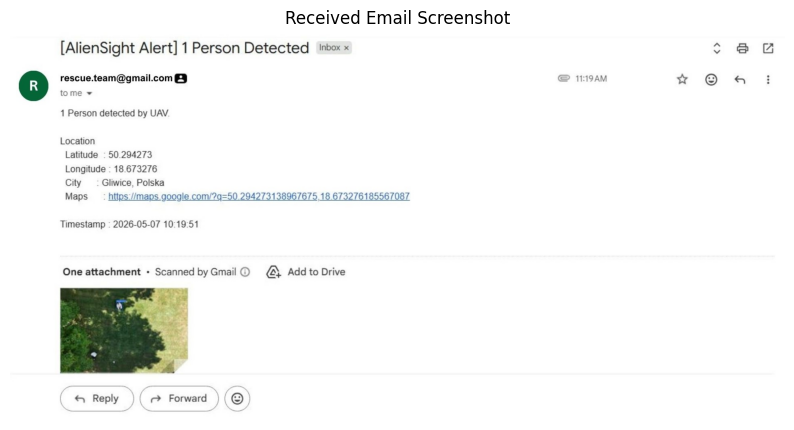

In [41]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_path = 'Received_email.JPG'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title('Received Email Screenshot')
    plt.axis('off') # Hide axes ticks
    plt.show()
else:
    print(f"Error: Image not found at {image_path}")


# **Inspect Detection Results**

In [42]:
import pandas as pd

df = pd.read_csv(OUTPUT_CSV)

print(f"Total detections : {len(df)}")
print(f"Frames with hits : {df['frame_id'].nunique()}")
print(f"Avg confidence   : {df['conf'].mean():.3f}")
print(f"Altitude range   : {df['altitude'].min():.1f} – {df['altitude'].max():.1f} m")
print()
df.head(10)

Total detections : 300
Frames with hits : 300
Avg confidence   : 0.838
Altitude range   : 15.0 – 15.0 m



,frame_id,drone_lat,drone_lon,altitude,person_idx,bbox_x1,bbox_y1,bbox_x2,bbox_y2,est_lat,est_lon,conf
0,0,50.294238,18.673287,15.0,1,862,179,933,284,50.294273,18.673275,0.9111
1,1,50.294238,18.673287,15.0,1,862,183,933,290,50.294273,18.673275,0.9076
2,2,50.294238,18.673287,15.0,1,859,188,932,289,50.294272,18.673274,0.8647
3,3,50.294238,18.673287,15.0,1,859,194,933,293,50.294272,18.673274,0.8911
4,4,50.294238,18.673287,15.0,1,859,198,932,302,50.294271,18.673274,0.9129
5,5,50.294238,18.673287,15.0,1,856,203,931,303,50.294271,18.673274,0.8844
6,6,50.294238,18.673287,15.0,1,855,210,932,308,50.294270,18.673274,0.8930
7,7,50.294238,18.673287,15.0,1,857,213,930,313,50.294269,18.673274,0.8841
8,8,50.294238,18.673287,15.0,1,856,220,931,320,50.294269,18.673274,0.8657
9,9,50.294238,18.673287,15.0,1,855,225,929,322,50.294268,18.673274,0.8604


# **Export Annotated Video**

In [43]:
import cv2
import csv
import os
from collections import defaultdict
from tqdm import tqdm

# ── Settings ──────────────────────────────────────────────
VIDEO_PATH   = "data/15m90d.mp4"
CSV_PATH     = "data/detections.csv"
OUTPUT_VIDEO = "data/annotated_output.mp4"

# Must match your CAMERA["fps"] config
TARGET_FPS  = 30

# ── Load CSV grouped by frame_id ───────────────────────────
detections_by_frame = defaultdict(list)

if not os.path.exists(CSV_PATH):
    print(f"[ERROR] CSV not found at {CSV_PATH}. Run the detection cell first!")
else:
    with open(CSV_PATH, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            detections_by_frame[int(row["frame_id"])].append({
                "bbox"   : (int(row["bbox_x1"]), int(row["bbox_y1"]),
                            int(row["bbox_x2"]), int(row["bbox_y2"])),
                "est_lat": row["est_lat"],
                "est_lon": row["est_lon"],
            })

# ── Video Setup ────────────────────────────────────────────
cap        = cv2.VideoCapture(VIDEO_PATH)
actual_fps = cap.get(cv2.CAP_PROP_FPS)
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Calculate frame skip to match your detection logic
frame_skip = max(1, round(actual_fps / TARGET_FPS))

# Use 'mp4v' for standard MP4 or 'avc1' for better web compatibility
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, TARGET_FPS, (width, height))

print(f"[Video] Total Frames: {total_frames}")
print(f"[Video] Actual FPS: {actual_fps:.2f} → Target FPS: {TARGET_FPS}")
print(f"[Video] Reading every {frame_skip} frame(s)")

# ── Style ──────────────────────────────────────────────────
BOX_COLOR  = (255, 100, 0)   # Blue-ish
TEXT_COLOR = (255, 255, 255) # White
FONT       = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.8
THICKNESS  = 2

# ── Main Loop ──────────────────────────────────────────────
frame_id     = 0   # Raw video frame counter
processed_id = 0   # Counter for processed (non-skipped) frames
pbar = tqdm(total=total_frames, desc="Writing Annotated Video")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Only process and write the frames that were analyzed in the detection cell
    if frame_id % frame_skip == 0:
        # Draw detections if any exist for this logical index
        for det in detections_by_frame.get(processed_id, []):
            x1, y1, x2, y2 = det["bbox"]
            label = f"person: {det['est_lat']}, {det['est_lon']}"

            # 1. Draw Bounding Box
            cv2.rectangle(frame, (x1, y1), (x2, y2), BOX_COLOR, 3)

            # 2. Draw Label Background
            (tw, th), _ = cv2.getTextSize(label, FONT, FONT_SCALE, THICKNESS)
            lx, ly = x1, max(y1 - th - 10, 0)
            cv2.rectangle(frame, (lx, ly), (lx + tw + 6, ly + th + 10), BOX_COLOR, -1)

            # 3. Draw Label Text
            cv2.putText(frame, label, (lx + 3, ly + th + 4),
                        FONT, FONT_SCALE, TEXT_COLOR, THICKNESS, cv2.LINE_AA)

        # Write the frame to the new video file
        writer.write(frame)
        processed_id += 1

    frame_id += 1
    pbar.update(1)

# ── Cleanup ────────────────────────────────────────────────
cap.release()
writer.release()
pbar.close()

print(f"\n[Success] Processed {processed_id} frames.")
print(f"[Success] Video saved to: {OUTPUT_VIDEO}")

[Video] Total Frames: 599
[Video] Actual FPS: 59.94 → Target FPS: 30
[Video] Reading every 2 frame(s)


Writing Annotated Video: 100%|██████████| 599/599 [00:18<00:00, 32.23it/s]


[Success] Processed 300 frames.
[Success] Video saved to: data/annotated_output.mp4


#First frame of the annotated video

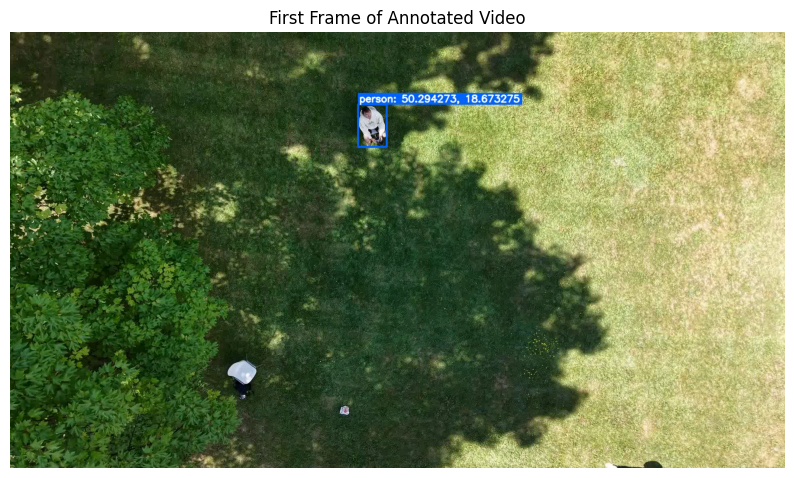

In [44]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)

if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    ret, frame = cap.read()
    if ret:
        # Convert BGR to RGB for displaying with matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title("First Frame of Annotated Video")
        plt.axis('off') # Hide axes ticks
        plt.show()
    else:
        print("Error: Could not read the first frame.")
    cap.release()
